# Homework: Inverted Pendulum World Model Training

This notebook runs the official homework workflow: install dependencies, generate MuJoCo ground-truth windows, train the starter world model, evaluate locked nMSE/VPT scoreboard metrics, and plot diagnostics.

The assignment trains **one dynamics world model**. It does not train a policy, does not use reward, and does not use actor-critic updates.

The public scoreboard is for debugging and comparison. Official grading uses TA-private data generated with hidden seeds.

## 1. Configure Repository

**This file (`Assignment2_colab.ipynb`)** — set `COURSE_REPO_URL` to your fork. With **`TRAIN_ON_PUBLIC_SCOREBOARD = True`** (default), sections 4–7 train and evaluate on **`configs/public_scoreboard.yaml`** (`max_horizon=1000`), matching long-roll metrics in `configs/student.yaml`. The setup cell runs **`git pull`** so Colab picks up your latest push.

In [3]:
from pathlib import Path
import os
import subprocess
import sys

COURSE_REPO_URL = "https://github.com/vandanacm/EEC289A_WorldModel-Homework.git"
COURSE_REPO_BRANCH = "main"
SMOKE_RUN = False  # Full public profile by default.
RUN_SCOREBOARD_DEMO = True  # Generate/evaluate configs/public_scoreboard.yaml windows by default.
# Train/eval on long windows (max_horizon=1000). Required if configs/student.yaml uses rollout_train_horizon > ~99.
TRAIN_ON_PUBLIC_SCOREBOARD = True

def run(cmd, cwd=None):
    cmd = [str(part) for part in cmd]
    print("+", " ".join(cmd))
    return subprocess.run(cmd, cwd=cwd, check=True)

def find_existing_repo(start: Path):
    for path in [start, *start.parents]:
        if (path / "wm_hw").is_dir() and (path / "configs" / "dev.yaml").exists():
            return path
    return None

def default_clone_dir():
    content = Path("/content")
    if content.exists() and os.access(content, os.W_OK):
        return content / "wm_inverted_pendulum_hw"
    return Path.home() / "wm_inverted_pendulum_hw"

repo = find_existing_repo(Path.cwd())
if repo is None:
    repo = default_clone_dir()
    if not (repo / ".git").exists():
        run(["git", "clone", "--branch", COURSE_REPO_BRANCH, COURSE_REPO_URL, repo])
    else:
        print(f"Using existing repo at {repo}")

if (repo / ".git").exists():
    try:
        run(["git", "-C", str(repo), "pull", "--ff-only", "origin", COURSE_REPO_BRANCH])
    except subprocess.CalledProcessError as exc:
        print("git pull skipped/failed (offline or local edits):", exc)

COURSE_REPO_DIR = repo.resolve()
print("COURSE_REPO_DIR =", COURSE_REPO_DIR)

+ git clone --branch main https://github.com/vandanacm/EEC289A_WorldModel-Homework.git /content/wm_inverted_pendulum_hw
+ git -C /content/wm_inverted_pendulum_hw pull --ff-only origin main
COURSE_REPO_DIR = /content/wm_inverted_pendulum_hw


## 2. Install Dependencies And Verify MuJoCo

In [4]:
%cd {COURSE_REPO_DIR}
!{sys.executable} -m pip install -q -U pip wheel "setuptools<82"
!{sys.executable} -m pip install -q -r requirements.txt

import gymnasium as gym
import torch

env = gym.make("InvertedPendulum-v5", reset_noise_scale=0.01)
obs, info = env.reset(seed=0)
print("obs shape:", obs.shape)
print("action shape:", env.action_space.shape)
print("action range:", env.action_space.low, env.action_space.high)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
env.close()

/content/wm_inverted_pendulum_hw
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 69.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
obs shape: (4,)
action shape: (1,)
action range: [-3.] [3.]
torch: 2.10.0+cu128
cuda available: True


## 3. Run Tests

These tests check the environment, dataset schema, no-leak open-loop rollout, differentiable loss, locked VPT/nMSE metrics, and train/eval smoke path.

In [5]:
!{sys.executable} -m pytest -q -m "not slow"

.............                                                            [100%]
13 passed, 1 deselected in 5.24s


## 4. Generate MuJoCo Ground-Truth Windows

In [6]:
smoke_flag = "--smoke" if SMOKE_RUN else ""
if SMOKE_RUN:
    DATASET_DIR = "data/dev_smoke"
    DATASET_CONFIG = "configs/dev.yaml"
elif TRAIN_ON_PUBLIC_SCOREBOARD:
    DATASET_DIR = "data/public_scoreboard"
    DATASET_CONFIG = "configs/public_scoreboard.yaml"
else:
    DATASET_DIR = "data/dev"
    DATASET_CONFIG = "configs/dev.yaml"
print("Dataset config:", DATASET_CONFIG, "->", DATASET_DIR)
!{sys.executable} -m wm_hw.dataset --config {DATASET_CONFIG} --output-dir {DATASET_DIR} {smoke_flag}

Dataset config: configs/public_scoreboard.yaml -> data/public_scoreboard
{
  "output_dir": "data/public_scoreboard",
  "written": {
    "train": "data/public_scoreboard/train.npz",
    "val": "data/public_scoreboard/val.npz",
    "test": "data/public_scoreboard/test.npz",
    "ood": "data/public_scoreboard/ood.npz"
  },
  "metadata": {
    "env_id": "InvertedPendulum-v5",
    "seed": 289,
    "smoke": false,
    "warmup_steps": 10,
    "max_horizon": 1000,
    "window_states": 1011,
    "window_actions": 1010,
    "action_range": [
      -3.0,
      3.0
    ],
    "splits": {
      "train": {
        "states": [
          1024,
          1011,
          4
        ],
        "actions": [
          1024,
          1010,
          1
        ]
      },
      "val": {
        "states": [
          256,
          1011,
          4
        ],
        "actions": [
          256,
          1010,
          1
        ]
      },
      "test": {
        "states": [
          256,
          1011,
  

## 5. Train The Starter World Model

In [7]:
!{sys.executable} -m wm_hw.train --config configs/student.yaml --model student --dataset-dir {DATASET_DIR} --output-dir artifacts/student {smoke_flag}

[train] model=student device=cuda updates=8000 smoke=False
[train] update=1 loss/total=2.3297 loss/one_step=1.0007 loss/rollout=0.8860 max_horizon=1000.0000 nMSE_AUC=1.1319 nMSE@1=0.2051 step_nMSE@1=0.2051 nMSE@5=0.5028 step_nMSE@5=0.7130 nMSE@10=0.6508 step_nMSE@10=0.8353 nMSE@90=0.9917 step_nMSE@90=1.2056 nMSE@100=1.0133 step_nMSE@100=1.2293 nMSE@200=1.1004 step_nMSE@200=1.1603 nMSE@500=1.1693 step_nMSE@500=1.2757 nMSE@1000=1.2004 step_nMSE@1000=1.1570 VPT80@0.10=0.0000 VPT50@0.10=1.0000 VPT80@0.25=0.0000 VPT50@0.25=1.0000 VPT80@0.50=1.0000 VPT50@0.50=3.0000 warmup_steps=10.0000 one_step_rmse=0.0736 open_loop_rmse@horizon=0.2439
[train] update=250 loss/total=0.4946 loss/one_step=0.0319 loss/rollout=0.3085 max_horizon=1000.0000 nMSE_AUC=0.8344 nMSE@1=0.0350 step_nMSE@1=0.0350 nMSE@5=0.1068 step_nMSE@5=0.1661 nMSE@10=0.1581 step_nMSE@10=0.2373 nMSE@90=0.2882 step_nMSE@90=0.4143 nMSE@100=0.3013 step_nMSE@100=0.4205 nMSE@200=0.4945 step_nMSE@200=0.8899 nMSE@500=0.9747 step_nMSE@500=1.370

## 6. Evaluate Test And OOD VPT Scoreboard

In [8]:
!{sys.executable} -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir {DATASET_DIR} --split test --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/eval_test
!{sys.executable} -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir {DATASET_DIR} --split ood --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/eval_ood

{
  "metrics_summary": {
    "max_horizon": 1000,
    "VPT80@0.25": 24,
    "VPT50@0.25": 29,
    "nMSE_AUC": 0.21444584429264069,
    "nMSE@10": 0.0013031525304540992,
    "nMSE@90": 0.15692885220050812,
    "nMSE@100": 0.16104522347450256,
    "nMSE@1000": 0.2787622809410095,
    "step_nMSE@10": 0.0035937426146119833,
    "step_nMSE@100": 0.18908295035362244,
    "step_nMSE@1000": 0.515878438949585,
    "one_step_rmse": 0.022355087101459503,
    "open_loop_rmse@horizon": 0.10889626294374466
  },
  "metrics_json": "artifacts/student/eval_test/metrics.json",
  "scoreboard_summary_json": "artifacts/student/eval_test/scoreboard_summary.json",
  "per_window_vpt_0p25": "artifacts/student/eval_test/per_window_vpt_0p25.npy"
}
{
  "metrics_summary": {
    "max_horizon": 1000,
    "VPT80@0.25": 22,
    "VPT50@0.25": 27,
    "nMSE_AUC": 0.21772626042366028,
    "nMSE@10": 0.0015295755583792925,
    "nMSE@90": 0.1603214144706726,
    "nMSE@100": 0.16399917006492615,
    "nMSE@1000": 0.2843517661

## 7. Plot Diagnostics

{'survival_curve': 'artifacts/student/plots/survival_curve.png', 'rollout_comparison': 'artifacts/student/plots/rollout_comparison.png'}
test VPT80@0.25: 24
ood VPT80@0.25: 22
test max_horizon: 1000
test nMSE_AUC: 0.21444584429264069


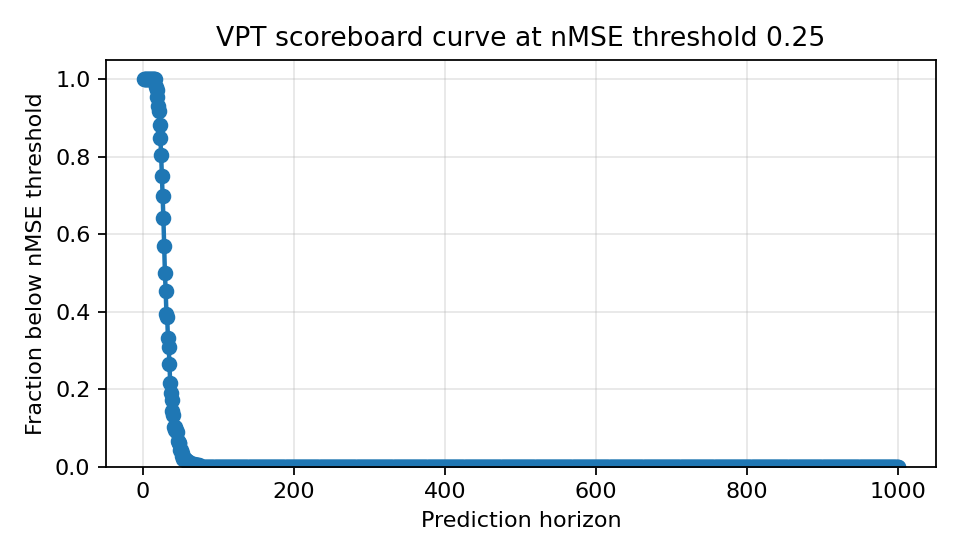

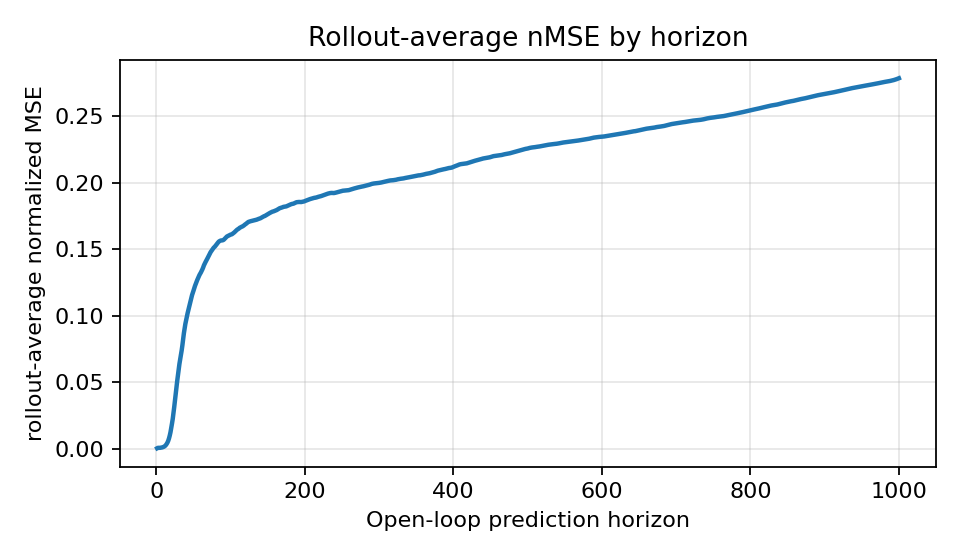

In [9]:
!{sys.executable} -m wm_hw.plotting --eval-dir artifacts/student/eval_test --output-dir artifacts/student/plots

import json
from IPython.display import Image, display

with open("artifacts/student/eval_test/metrics.json", "r", encoding="utf-8") as f:
    test_metrics = json.load(f)
with open("artifacts/student/eval_ood/metrics.json", "r", encoding="utf-8") as f:
    ood_metrics = json.load(f)

print("test VPT80@0.25:", test_metrics["VPT80@0.25"])
print("ood VPT80@0.25:", ood_metrics["VPT80@0.25"])
print("test max_horizon:", test_metrics["max_horizon"])
print("test nMSE_AUC:", test_metrics["nMSE_AUC"])
display(Image("artifacts/student/plots/survival_curve.png"))
display(Image("artifacts/student/plots/rollout_comparison.png"))

## 8. Optional Long-Horizon Scoreboard

If `TRAIN_ON_PUBLIC_SCOREBOARD = True` in cell 1, section 4 already built `data/public_scoreboard`; section 8 will **reuse** it and skip regenerating. Set `RUN_SCOREBOARD_DEMO = True` and `SMOKE_RUN = False` for the zip + `scoreboard_summary` artifacts. Same config: `warmup_steps=10`, `max_horizon=1000`.

In [10]:
if RUN_SCOREBOARD_DEMO:
    import json
    from pathlib import Path
    assert not SMOKE_RUN, "Final scoreboard artifacts require SMOKE_RUN = False."
    SCOREBOARD_DIR = "data/public_scoreboard"
    if TRAIN_ON_PUBLIC_SCOREBOARD and Path(SCOREBOARD_DIR).exists():
        print("Reusing", SCOREBOARD_DIR, "(already generated in section 4).")
    else:
        run([sys.executable, "-m", "wm_hw.dataset", "--config", "configs/public_scoreboard.yaml", "--output-dir", SCOREBOARD_DIR])
    run([sys.executable, "-m", "wm_hw.eval_horizon", "--checkpoint-dir", "artifacts/student/best_checkpoint", "--dataset-dir", SCOREBOARD_DIR, "--split", "test", "--horizon", "auto", "--eval-config", "configs/official_eval.yaml", "--output-dir", "artifacts/student/public_scoreboard_test"])
    run([sys.executable, "-m", "wm_hw.plotting", "--eval-dir", "artifacts/student/public_scoreboard_test", "--output-dir", "artifacts/student/public_scoreboard_plots"])
    run(["bash", "-lc", "cd artifacts/student && zip -qr final_artifacts.zip best_checkpoint eval_test eval_ood plots public_scoreboard_test public_scoreboard_plots"])
    with open("artifacts/student/public_scoreboard_test/scoreboard_summary.json", "r", encoding="utf-8") as f:
        print(json.load(f))
else:
    print("Set RUN_SCOREBOARD_DEMO = True in the first cell to run the long-horizon scoreboard demo.")

Reusing data/public_scoreboard (already generated in section 4).
+ /usr/bin/python3 -m wm_hw.eval_horizon --checkpoint-dir artifacts/student/best_checkpoint --dataset-dir data/public_scoreboard --split test --horizon auto --eval-config configs/official_eval.yaml --output-dir artifacts/student/public_scoreboard_test
+ /usr/bin/python3 -m wm_hw.plotting --eval-dir artifacts/student/public_scoreboard_test --output-dir artifacts/student/public_scoreboard_plots
+ bash -lc cd artifacts/student && zip -qr final_artifacts.zip best_checkpoint eval_test eval_ood plots public_scoreboard_test public_scoreboard_plots
{'VPT50@0.25': 29, 'VPT80@0.25': 24, 'VPT80_fraction': 0.024, 'checkpoint_step': 8000, 'max_horizon': 1000, 'model_name': 'student', 'nMSE@10': 0.0013031525304540992, 'nMSE@100': 0.16104522347450256, 'nMSE@1000': 0.2787622809410095, 'nMSE@90': 0.15692885220050812, 'nMSE_AUC': 0.21444584429264069, 'primary_metric': 'VPT80@0.25', 'step_nMSE@10': 0.0035937426146119833, 'step_nMSE@100': 0.